In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# -------------------------------
# Load MNIST Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# -------------------------------
# Function to Create Model
# -------------------------------
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [9]:
# -------------------------------
# Train with SGD
# -------------------------------
model_sgd = create_model()
model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

C:\Users\Ananthimerciya M\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8187 - loss: 0.7040 - val_accuracy: 0.9093 - val_loss: 0.3281
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9117 - loss: 0.3101 - val_accuracy: 0.9269 - val_loss: 0.2616
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9269 - loss: 0.2542 - val_accuracy: 0.9377 - val_loss: 0.2263
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9373 - loss: 0.2182 - val_accuracy: 0.9452 - val_loss: 0.2006
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9453 - loss: 0.1916 - val_accuracy: 0.9491 - val_loss: 0.1803


In [11]:
# -------------------------------
# Train with RMSProp
# -------------------------------
model_rms = create_model()
model_rms.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_rms = model_rms.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9234 - loss: 0.2607 - val_accuracy: 0.9599 - val_loss: 0.1426
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9655 - loss: 0.1148 - val_accuracy: 0.9686 - val_loss: 0.1067
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9751 - loss: 0.0828 - val_accuracy: 0.9692 - val_loss: 0.1152
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9803 - loss: 0.0658 - val_accuracy: 0.9722 - val_loss: 0.1023
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9841 - loss: 0.0534 - val_accuracy: 0.9707 - val_loss: 0.1166


In [12]:
# -------------------------------
# Train with Adam
# -------------------------------
model_adam = create_model()
model_adam.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9245 - loss: 0.2630 - val_accuracy: 0.9585 - val_loss: 0.1320
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9663 - loss: 0.1098 - val_accuracy: 0.9647 - val_loss: 0.1093
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9762 - loss: 0.0761 - val_accuracy: 0.9688 - val_loss: 0.1002
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9822 - loss: 0.0577 - val_accuracy: 0.9661 - val_loss: 0.1046
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9868 - loss: 0.0430 - val_accuracy: 0.9742 - val_loss: 0.0862


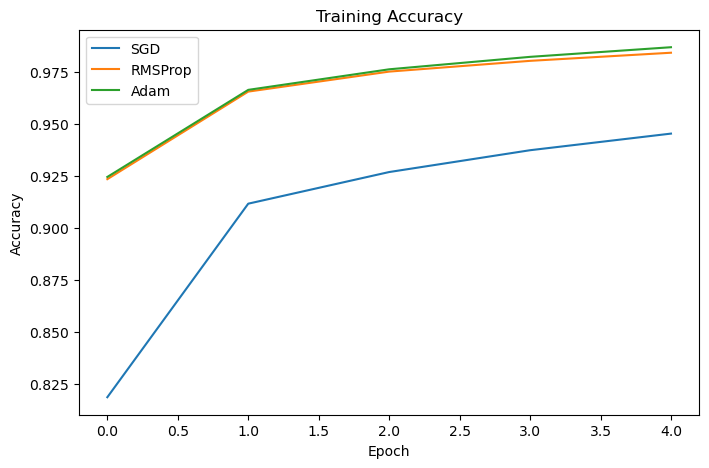

In [13]:
# -------------------------------
# Plot Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_rms.history['accuracy'], label='RMSProp')
plt.plot(history_adam.history['accuracy'], label='Adam')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

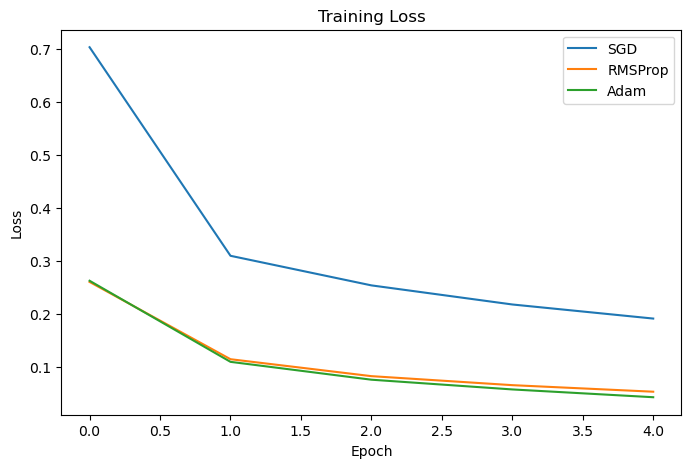

In [14]:
# -------------------------------
# Plot Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_rms.history['loss'], label='RMSProp')
plt.plot(history_adam.history['loss'], label='Adam')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
# -------------------------------
# Evaluate Models
# -------------------------------
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
rms_loss, rms_acc = model_rms.evaluate(x_test, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

In [18]:
# -------------------------------
# Comparison Table
# -------------------------------
results = pd.DataFrame({
    "Optimizer": ["SGD", "RMSProp", "Adam"],
    "Accuracy": [sgd_acc, rms_acc, adam_acc],
    "Loss": [sgd_loss, rms_loss, adam_loss]
})

print("\nOptimizer Comparison")
print(results)


Optimizer Comparison
  Optimizer  Accuracy      Loss
0       SGD    0.9476  0.179992
1   RMSProp    0.9749  0.095409
2      Adam    0.9762  0.081183


In [19]:
# -------------------------------
# Best Optimizer
# -------------------------------
best = results.loc[results["Accuracy"].idxmax()]

print("\nBest Optimizer:", best["Optimizer"])
print("Highest Accuracy:", round(best["Accuracy"], 4))
print("Lowest Loss:", round(best["Loss"], 4))

print("\nConclusion:")
print(f"{best['Optimizer']} performed the best because it achieved the highest accuracy ({best['Accuracy']:.4f}) and the lowest loss ({best['Loss']:.4f}).")


Best Optimizer: Adam
Highest Accuracy: 0.9762
Lowest Loss: 0.0812

Conclusion:
Adam performed the best because it achieved the highest accuracy (0.9762) and the lowest loss (0.0812).
